In [1]:
import datajoint as dj
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
import scipy
from tqdm import tqdm

from staticnet_analyses import gabors
from staticnet_pilots.analyses import * 
from staticnet_invariance import deis_reconfigured as deis_schema#, dei_stimulus as old_dei_stimulus
from staticnet_invariance import toy_deis as toy 
from staticnet_invariance.toy import GroupAssignment, ToyNeuron
from staticnet_invariance.deis_reconfigured import process_p_and_act
# plt.rcParams['font.family'] = ['sans-serif']
# plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

imagenet = dj.create_virtual_module('pipeline_imagenet', 'pipeline_imagenet')
experiment = dj.create_virtual_module('pipeline_experiment', 'pipeline_experiment')
meso = dj.create_virtual_module('pipeline_meso', 'pipeline_meso')
collection = dj.create_virtual_module('collection', 'pipeline_collection')

import pickle
# with open('/src/static-networks/closed_loop_bad_matching_neurons_by_visual_inspection_on_summary_images.pickle', 'rb') as handle:
#     manual_exclude_dic = pickle.load(handle)
with open('/dj-stor01/users/zhiwei/closed_loop_bad_matching_neurons_by_visual_inspection_on_summary_images.pickle', 'rb') as handle:
    manual_exclude_dic = pickle.load(handle)
    
def get_exclude_neurons(manual_exclude_dic, corr_thresh=0.42, dist_thresh=10, exclude_type='confusion', mei_key=None):
    if exclude_type == 'confusion':
        manual_exclude = manual_exclude_dic['{}-{}-{}'.format(*mei_key.values())]
        neuron_dics = (DEIClosedLoopSummaryResults.Neuron() & mei_key).fetch('neuron_id', 'matched_corr', 'matched_distance', as_dict=True, order_by='neuron_id')
        exclude_cols = [i for i, dic in enumerate(neuron_dics) if (dic['neuron_id'] in manual_exclude) or (dic['matched_corr'] < corr_thresh) or (dic['matched_distance'] > dist_thresh)]
        return exclude_cols
    else:
        manual_exclude = []
        for key, val in zip(manual_exclude_dic.keys(), manual_exclude_dic.values()):
            manual_exclude.extend([dict(animal_id=key.split('-')[0], session=key.split('-')[1], scan_idx=key.split('-')[2], neuron_id=n) for n in val])

        rel1 = DEIClosedLoopSummaryResults.Neuron & 'group_id in (241)'
        rel2 = DEIClosedLoopSummaryResults.Neuron & manual_exclude
        rel3 = DEIClosedLoopSummaryResults.Neuron & 'group_id not in (241) and matched_corr < {} or matched_distance > {}'.format(corr_thresh, dist_thresh)
        rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 7 and scan_idx = 12'
        # rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 6 and scan_idx = 8' # accidentally showed exact same stimuli for 27470-6-8 and 27470-7-12

        return rel1.proj() + rel2.proj() + rel3.proj() + rel4.proj()
    

Connecting zhiwei@at-database.stanford.edu:3306


/src/static-networks/staticnet_analyses/multi_mei.py:1648: UserWarning: Use of this table is deprecated. It is kept only for record keeping purpose
  warnings.warn('Use of this table is deprecated. It is kept only for record keeping purpose')


In [2]:
groups = [233, 237, 239, 243, 271, 272, 275, 279, 284, 285, 329, 330, 336, 337]
net_hash = ["8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da"]
data_hash = ["7572eed73113c993e7d1b92f83e270b4"]

In [3]:
len(groups)

14

In [4]:
unique_units = base.UnitRanking.Unit & 'ranking_params = 4' & [{'group_id': i} for i in groups] & [{'net_hash': i} for i in net_hash] & [{'data_hash': i} for i in data_hash]
cc_max, cc_abs, cc_norm = (base.NewEnsembleEval.Unit & 'ssid = 1' & unique_units).fetch('cc_max', 'cc_abs', 'cc_norm', order_by='group_id, neuron_id')


In [5]:
len(unique_units)

33714

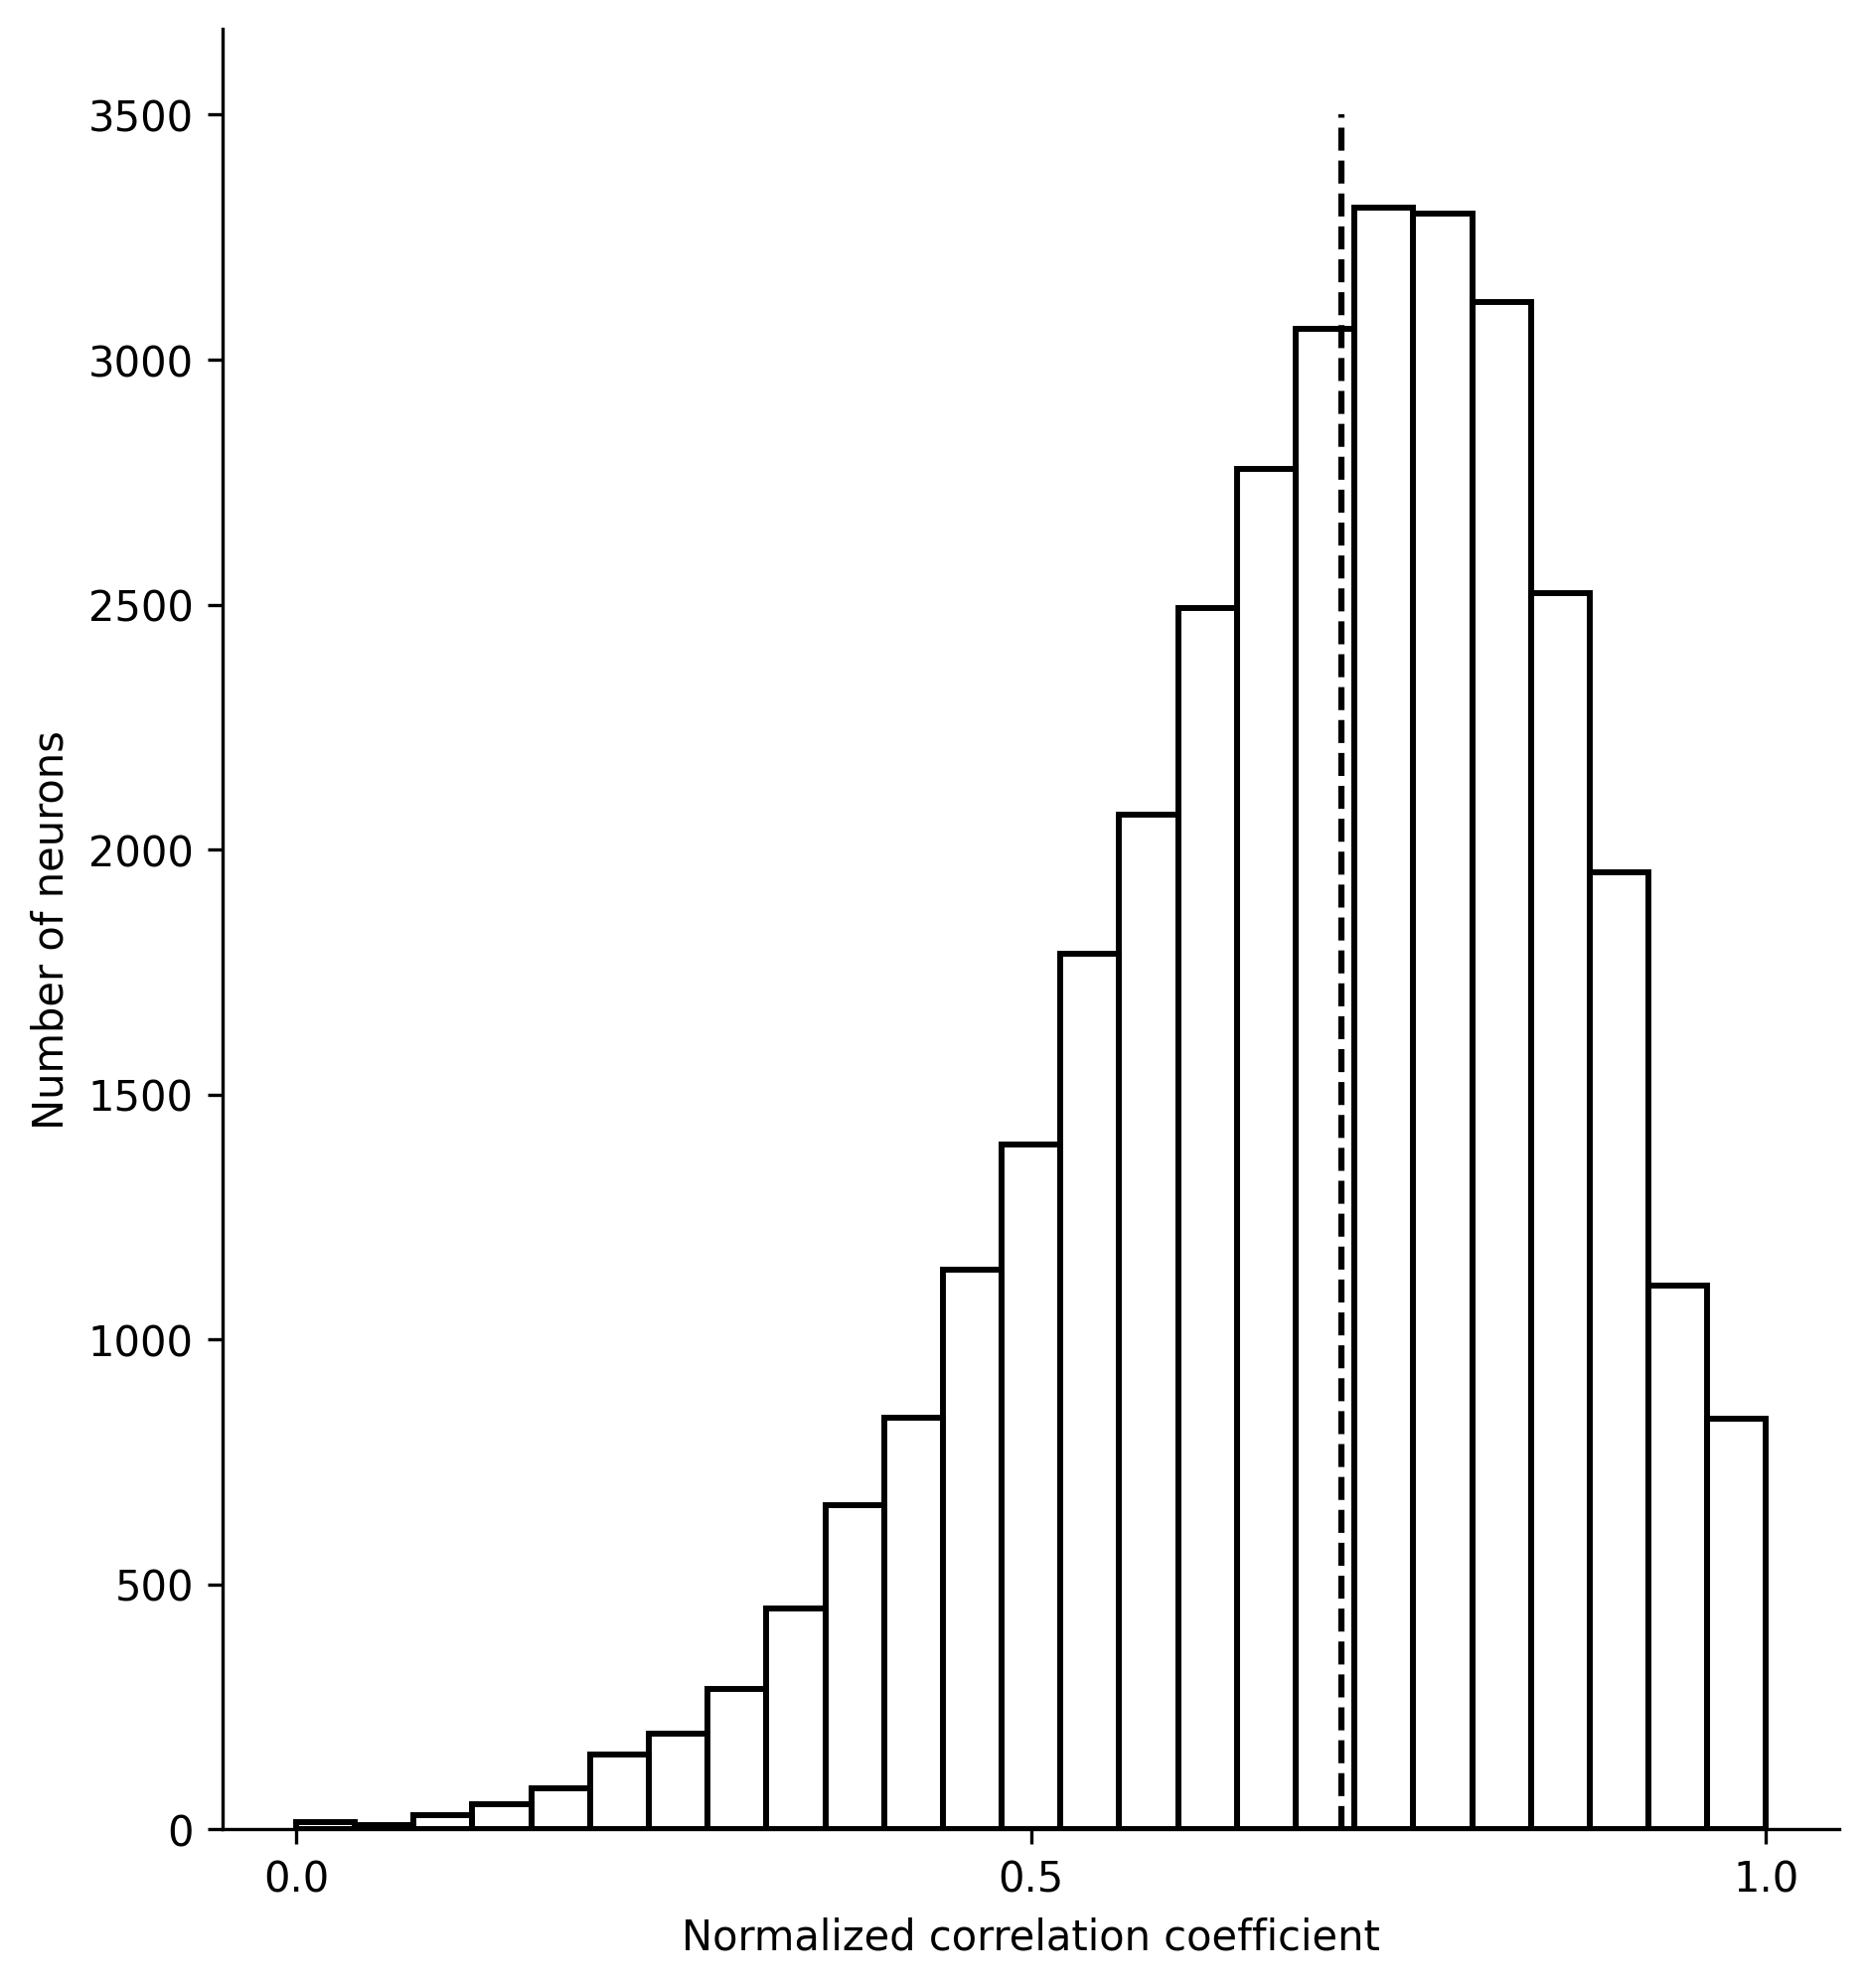

In [7]:
idxs = np.where(cc_max >= 0.1)[0]
plt.figure(figsize=(7, 8), dpi=300)
sns.histplot(np.clip(cc_norm[idxs], 0, 1), fill=False, color='k', bins=25, binrange=[0, 1])
plt.vlines(np.median(np.clip(cc_norm[idxs], 0, 1)), ymin=0, ymax=3500, linestyles='dashed', color='k')
# plt.xlim([0, 1])
plt.ylabel('Number of neurons')
plt.xlabel('Normalized correlation coefficient')
plt.xticks([0, 0.5, 1])
sns.despine()
plt.savefig('/src/notebooks/Official_figures/[Fig1_e]cc_norm_all_neurons.pdf', transparent=True)